In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
from pathlib import Path
from astropy.coordinates import SkyCoord
from astromodels.functions.function import Function1D, FunctionMeta
# from cosipy import SpacecraftFile
from cosipy import SourceInjector
from cosipy.response import FullDetectorResponse, ExtendedSourceResponse
from histpy import Histogram
from mhealpy import HealpixMap
from threeML import Powerlaw, Band, Model, PointSource, Gaussian, ExtendedSource, Gaussian_on_sphere
# from astromodels import ExtendedSource, Gaussian_on_sphere
from cosipy.threeml.custom_functions import SpecFromDat#, Wide_Asymm_Gaussian_on_sphere
from astromodels import Asymm_Gaussian_on_sphere
from cosipy.util import fetch_wasabi_file

import shutil
import os
import h5py as h5

In [4]:
DATA_DIR = Path("../../")

In [5]:
ori_path = DATA_DIR / 'DC3/data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori'

# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.parse_from_file(ori_path)

NameError: name 'SpacecraftFile' is not defined

In [6]:
def spectrum_reset(spec, F=None, mu=None, sigma=None):

    spec.F.min_value = F.value / 5
    spec.F.max_value = F.value * 5
    spec.F.value = F.value
    spec.F.unit = F.unit
    spec.mu.min_value = mu.value - 2
    spec.mu.max_value = mu.value + 2
    spec.mu.value = mu.value 
    spec.mu.unit = mu.unit
    spec.sigma.min_value = 0.2
    spec.sigma.max_value = sigma.value + 5
    spec.sigma.value = sigma.value
    spec.sigma.unit = sigma.unit

    spec.F.free = True
    spec.mu.free = True
    spec.sigma.free = True

    return spec

In [69]:
def simulate_point_sources(spec, rsp_path, point_sources, mu=1157.02, sig=3.85):
    # point_sources expected format
    ## list of tuples
    ## tuple[0] = Source Name
    ## tuple[1] = l in deg
    ## tuple[2] = b in deg
    ## tuple[3] = flux only scalar value
    injector = SourceInjector(response_path = rsp_path, response_frame='galactic')

    mu = mu * u.keV
    sigma = sig * u.keV

    for src in point_sources:
        # Define the coordinate of the point source
        source_coord = SkyCoord(l = src[1], b = src[2], frame = "galactic", unit = "deg")

        # define the point source
        F = src[3] / u.cm / u.cm / u.s
        spectrum = spectrum_reset(spec, F=F, mu=mu, sigma=sigma)
        point_source = PointSource(src[0], l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape=spectrum)

        # define the model. The model can contain multiple point sources.
        model = Model(point_source)

        file_path = f"{src[0]}.h5"

        # Check if the file exists and remove it if it does
        if os.path.exists(file_path):
            # raise FileExistsError
            os.remove(file_path)

        # Get the data of the injected source
        model_injected = injector.inject_model(model = model, make_spectrum_plot = True, data_save_path = file_path)

### 44Ti

16:52:33 WARNING   The current value of the parameter mu (0.0) was below the new minimum 1155.0.   ]8;id=154515;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=158886;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

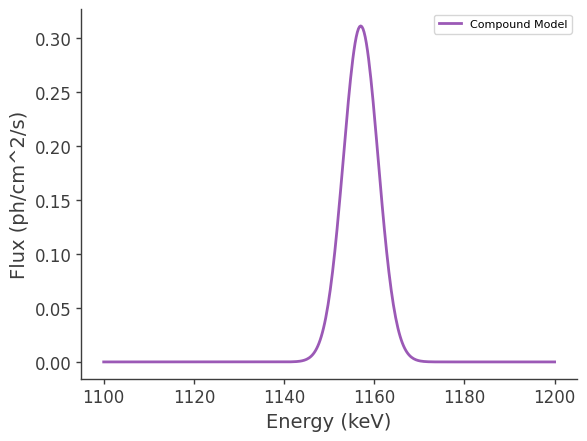

In [8]:
F = 3 / u.cm**2 / u.s
mu = 1157 * u.keV
sigma = 3.85 * u.keV
spectrum = spectrum_reset(Gaussian(), F, mu, sigma)

# Generate some data for plotting
x_data = np.linspace(1100, 1200, 401)
y_data = spectrum(x_data)

# Plot the compound model
plt.plot(x_data, y_data, label="Compound Model")
plt.xlabel("Energy (keV)")
plt.ylabel("Flux (ph/cm^2/s)")
plt.legend()
plt.show()

In [9]:
CasAsymmetric = 'CasAsymmetric', 111.734745, -2.129570, 3e-4        # 1000 km/s

SN1987A = 'SN1987A', 279.7, -31.9, 7e-6
Tycho = 'Tycho', 120.1, +1.4, 16e-6
Kepler = 'Kepler', 4.5, +6.8, 10e-6 
VelaJr = 'VelaJr', 266.3, -1.2, 28e-6
G1903 = 'G1903', 1.9, +0.3, 10e-6

STS1 = 'STS1', 80.2, +0.8, 1e-6
STS2 = 'STS2', 81.2, +0.9, 2e-6
STS3 = 'STS3', 84.0, -1.3, 1e-6
STS4 = 'STS4', 283.8, +75.5, 2e-6
STS5 = 'STS5', 184.6, -5.8, 1e-6
STS6 = 'STS6', 266.3, -49.7, 1e-6

known_SNRs = [SN1987A, Tycho, Kepler, VelaJr, G1903]
STS_SNRs = [STS1, STS2, STS3, STS4, STS5, STS6]

16:54:34 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=329043;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=348175;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  0.0014999999999999998.                                                                           

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1155.02.  ]8;id=662130;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=749346;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

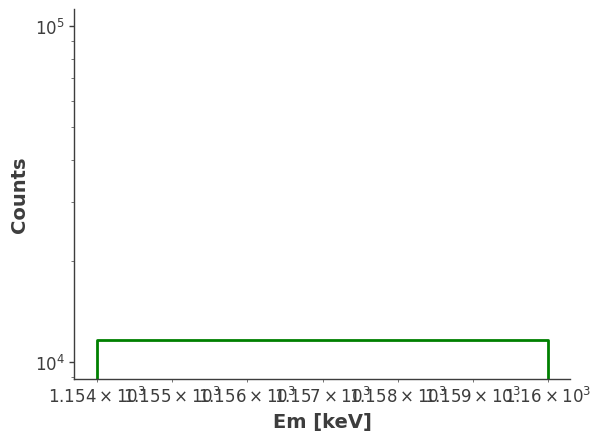

In [ ]:
simulate_point_sources(Gaussian(), response_path, [CasAsymmetric], sig=3.85 / 2.355)

In [ ]:
response_path = DATA_DIR / 'DC3/data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'

### 44Ti Imaging Components

In [ ]:
NGC_1068 = 'NGC_1068', 172.10, -51.93, 1e-8*1e3
P3_low = 'P3_low', 86.11, -38.18, 1e-7*1e3
unknown_src = 'unknown_src', 149.0625, -24.62, 1e-7*1e3

In [10]:
response_path = DATA_DIR / 'DC4/data/responses/extended_source_response_Ti44_merged.h5'

09:12:54 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0005.    ]8;id=958021;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=465999;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1155.02.  ]8;id=498769;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=340065;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

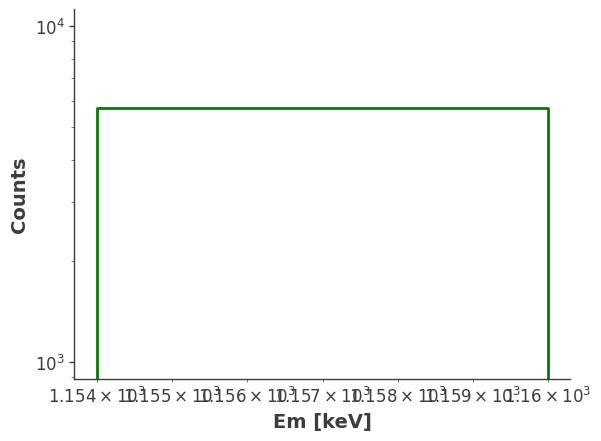

In [ ]:
simulate_point_sources(Gaussian(), response_path, [unknown_src], sig=3.85 / 10)

In [ ]:
NGC_inj = Histogram.open('NGC_1068.h5')
P3_inj = Histogram.open('P3_low.h5')
unknown_inj = Histogram.open('unknown_src.h5')

(<Mollview: >, <matplotlib.image.AxesImage at 0x321839750>)

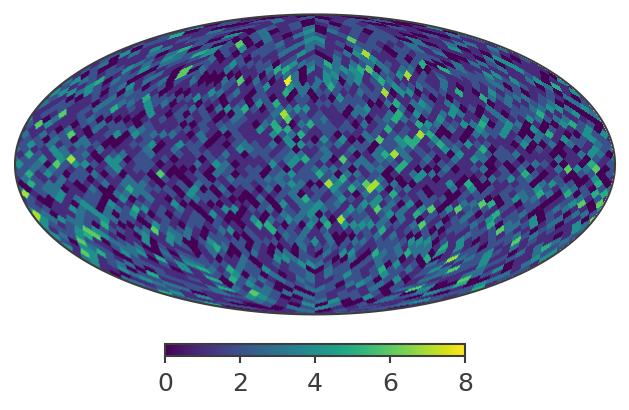

In [ ]:
(unknown_inj).project('PsiChi').plot()

In [ ]:
OrEr = 'OrEr', 163, -22, 5, 5, 0, 1e-4

09:22:12 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0005.    ]8;id=198434;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=525332;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1155.23.  ]8;id=191102;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=599336;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

(<Mollview: >, <matplotlib.image.AxesImage at 0x322583640>)

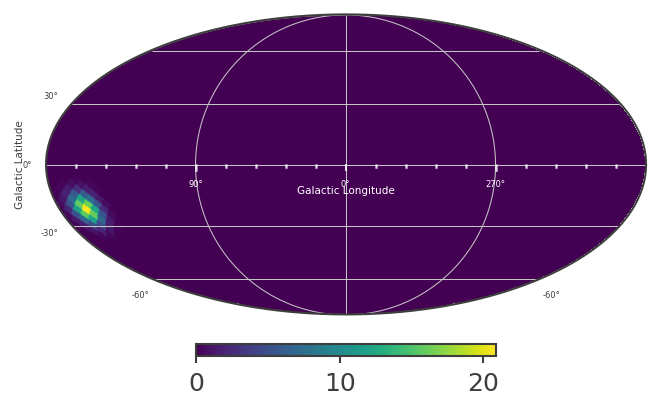

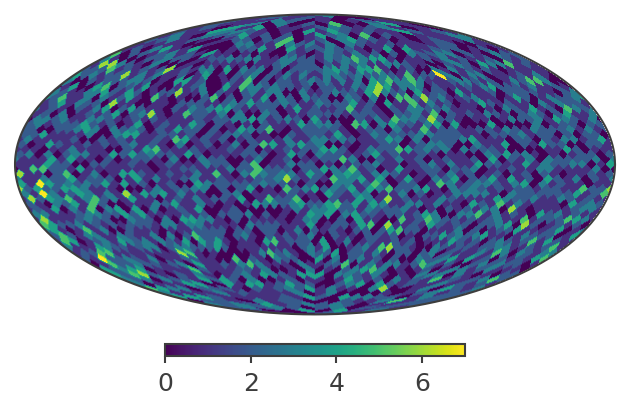

In [86]:
spectrum, morphology = simulate_extended_sources(Gaussian(), response_path, OrEr, mu=1157.23)
plot_morphology(morphology)
model_injected = Histogram.open(OrEr[0]+'.h5')
model_injected.project('PsiChi').plot()

#### Sanity Checks

In [ ]:
from cosipy import BinnedData
from histpy import Histogram
import numpy as np
import matplotlib.pyplot as plt

08:19:34 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=133291;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=872868;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=860070;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=966265;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=867848;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=159142;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=310349;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=508958;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

08:19:36 WARNING   No fermitools installed                                              ]8;id=700981;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=857445;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=340518;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=167182;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=286727;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=630575;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=153343;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=660891;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [ ]:
src = BinnedData('../../DC3/44Ti/inputs.yaml')
src.energy_bins = [1154, 1160]  # Takes list. Needs to match response.
src.time_bins = 86400 * 93      # time bin size in seconds. Takes int, float, or list of bin edges.
src.get_binned_data('../../DC3/44Ti/sources/CasAsymmetric_3months_unbinned_data_filtered_with_SAAcut.fits')

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


In [3]:
src.binned_data.axes.labels

array(['Time', 'Em', 'Phi', 'PsiChi'], dtype='<U6')

In [4]:
src_inj = Histogram.open('44Ti/CasAsymmetric.h5')

(10000.0, 15000.0)

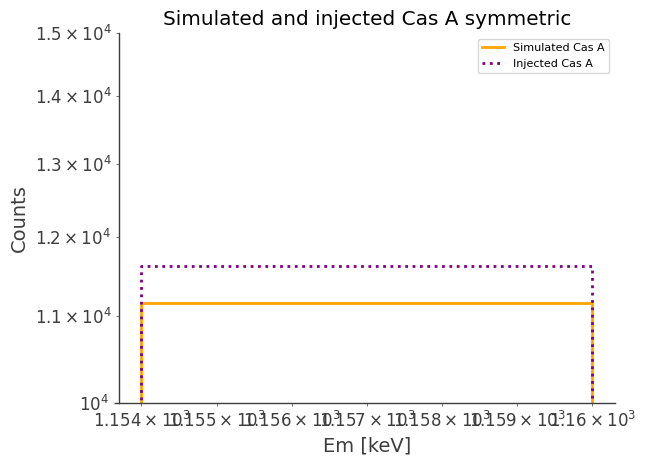

In [5]:
simulated = src.binned_data
injected = src_inj

ax,plot = simulated.project("Em").draw(label = "Simulated Cas A", color = "orange")
injected.project("Em").draw(ax, label = "Injected Cas A", color = "purple", linestyle = "dotted")

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Counts")
ax.set_title("Simulated and injected Cas A symmetric")
ax.set_ylim([1e4, 1.5e4])

Text(0.5, 1.0, 'Simulated and injected Cas A symmetric')

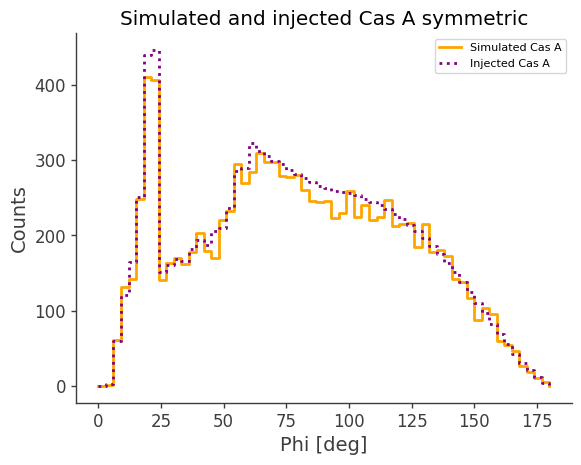

In [ ]:
ax,plot = simulated.project("Phi").draw(label = "Simulated Cas A", color = "orange")
injected.project("Phi").draw(ax, label = "Injected Cas A", color = "purple", linestyle = "dotted")

ax.legend()
ax.set_ylabel("Counts")
ax.set_title("Simulated and injected Cas A symmetric")

Text(0.5, 1.0, 'Simulated and injected Cas A symmetric')

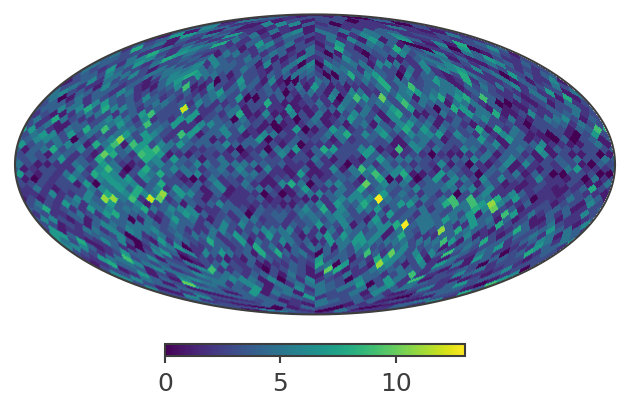

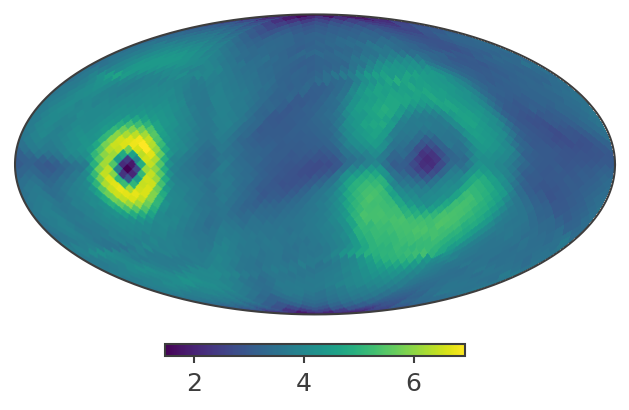

In [15]:
ax1,plot1 = simulated.project("PsiChi").draw(label = "Simulated Cas A")
ax2,plot2 = injected.project("PsiChi").draw(label = "Injected Cas A")

# ax1.legend()
# ax.set_ylabel("Counts")
ax.set_title("Simulated and injected Cas A symmetric")

### 26Al

#### Point Sources

In [6]:
point_sources_26Al = [('VelaJr26Al', 266.3, -1.2, 2e-5), ('gamma2velorum26Al', 262.8, -7.7, 1.1e-6)]
point_sources_60Fe_low = [('VelaJr60Fe_low', 266.3, -1.2, 4e-6)]
point_sources_60Fe_high = [('VelaJr60Fe_high', 266.3, -1.2, 4e-6)]

In [ ]:
200 / 3e5 * 1332.5

0.8883333333333333

17:18:12 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0001.    ]8;id=972752;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=853166;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=198634;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=277826;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

17:33:39 WARNING   The current value of the parameter F (2e-05) was above the new maximum 5.5e-06. ]8;id=898560;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=383808;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

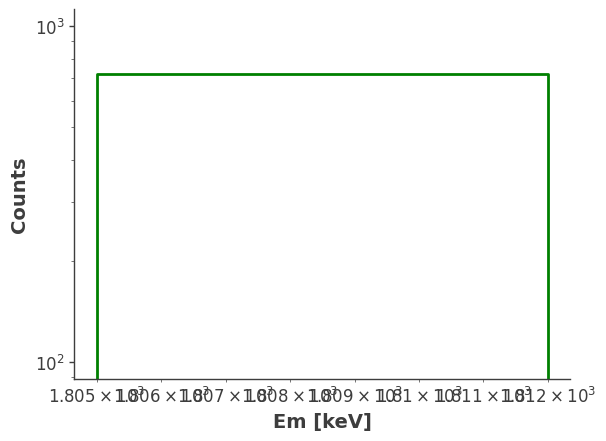

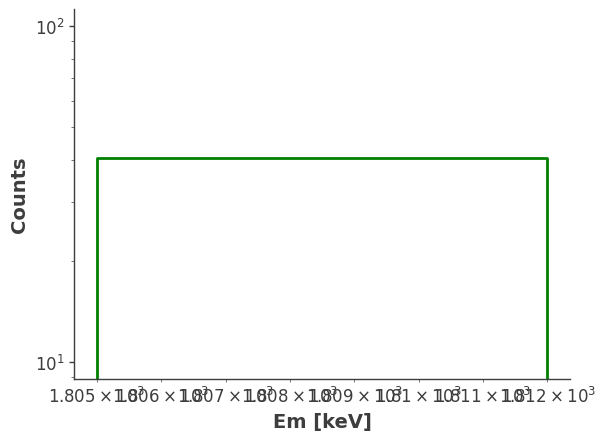

In [9]:
# 26Al
response_path_26Al = DATA_DIR / 'DC3/data/responses/Response26Al.o4.e1805_1812.s10036231691364.m1045.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_26Al, point_sources_26Al, sig=0.77, mu=1808.68)

17:44:02 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=965149;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=479851;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  1.9999999999999998e-05.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1171.23.  ]8;id=293409;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=655594;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

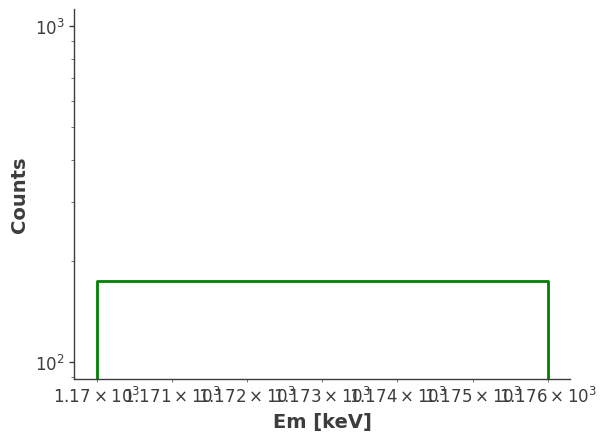

In [10]:
# 60Fe low
response_path_60Fe_low = DATA_DIR / 'DC3/data/responses/Response60FeLow.o4.e1170_1176.s9552269354945.m1188.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_60Fe_low, point_sources_60Fe_low, sig=0.77, mu=1173.23)

17:53:42 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=881518;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=568880;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  1.9999999999999998e-05.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1330.5.   ]8;id=338693;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=449888;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

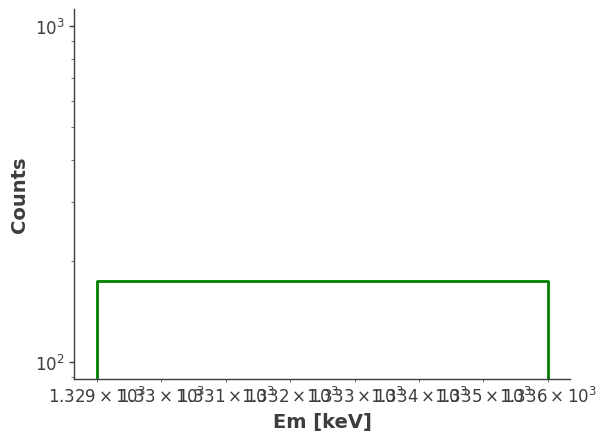

In [11]:
# 60Fe high
response_path_60Fe_high = DATA_DIR / 'DC3/data/responses/Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_60Fe_high, point_sources_60Fe_high, sig=0.77, mu=1332.5)

#### Extended Sources

In [8]:
USco_26Al = 'USco_26Al', 348.5, +22.5, 9, 9, 0, 6e-5        # TODO: theta values?
UCL_26Al = 'UCL_26Al', 322.5, +17.0, 15.5, 10.5, 0, 1e-5
LCC_26Al = 'LCC_26Al', 300.5, +6.5, 9, 9, 0, 1e-5
POB2_26Al = 'POB2_26Al', 168.5, -6.5, 6, 6, 0, 5e-5
VelaSNR_26Al = 'VelaSNR_26Al', 263.9, -3.4, 4.25, 4.25, 0, 1.4e-6
Gum_26Al = 'Gum_26Al', 258.0, -2.0, 18, 18, 0, 0.8e-6
OrEr_26Al = 'OrEr_26Al', 163.0, -22.0, 5, 5, 0, 3e-5
LMC_26Al = 'LMC_26Al', 280.5, -32.9, 3.5, 1.5, 0, 2e-6
IVS_26Al = 'IVS_26Al', 263.0, -7.0, 7.5, 7.5, 0, 1.1e-6

USco_60Fe = 'USco_60Fe', 348.5, +22.5, 9, 9, 0, 4.5e-5        # TODO: theta values?
UCL_60Fe = 'UCL_60Fe', 322.5, +17.0, 15.5, 10.5, 0, 1.5e-5
LCC_60Fe = 'LCC_60Fe', 300.5, +6.5, 9, 9, 0, 1.5e-5
POB2_60Fe = 'POB2_60Fe', 168.5, -6.5, 6, 6, 0, 4e-5
VelaSNR_60Fe = 'VelaSNR_60Fe', 263.9, -3.4, 4.25, 4.25, 0, 0.3e-6
Gum_60Fe = 'Gum_60Fe', 258.0, -2.0, 18, 18, 0, 0.2e-6
OrEr_60Fe = 'OrEr_60Fe', 163.0, -22.0, 5, 5, 0, 3e-5
LMC_60Fe = 'LMC_60Fe', 280.5, -32.9, 3.5, 1.5, 0, 0.5e-6
IVS_60Fe = 'IVS_60Fe', 263.0, -7.0, 7.5, 7.5, 0, 0.8e-6

In [80]:
def plot_spectrum(spectrum):
    # Generate some data for plotting
    if round(spectrum.mu.value) == 1773:
        x_data = np.linspace(1100, 1200, 401)
    elif round(spectrum.mu.value) == 1332:
        x_data = np.linspace(1300, 1400, 401)
    elif round(spectrum.mu.value) == 1809:
        x_data = np.linspace(1750, 1850, 401)
    y_data = spectrum(x_data)

    # Plot the compound model
    plt.plot(x_data, y_data)
    plt.xlabel("Energy (keV)")
    plt.ylabel("Flux (ph/cm^2/s)")
    # plt.legend()
    plt.show()

In [78]:
def plot_morphology(morphology):

    # Define healpix map matching the detector response:
    skymap = HealpixMap(nside = 16, scheme = "ring", dtype = float, coordsys='galactic')
    coords1 = skymap.pix2skycoord(range(skymap.npix))

    # Fill skymap with values from extended source: 
    skymap[:] = morphology(coords1.l.deg, coords1.b.deg) 

    # Plot healpix map:
    plot, ax = skymap.plot(ax_kw = {'coord':'G'})
    ax.grid()
    lon = ax.coords['glon']
    lat = ax.coords['glat']
    lon.set_axislabel('Galactic Longitude',color='white',fontsize=5)
    lat.set_axislabel('Galactic Latitude',fontsize=5)
    lon.display_minor_ticks(True)
    lat.display_minor_ticks(True)
    lon.set_ticks_visible(True)
    lon.set_ticklabel_visible(True)
    lon.set_ticks(color='white',alpha=0.6)
    lat.set_ticks(color='white',alpha=0.6)
    lon.set_ticklabel(color='white',fontsize=4)
    lat.set_ticklabel(fontsize=4)
    lat.set_ticks_visible(True)
    lat.set_ticklabel_visible(True)

In [85]:
def simulate_extended_sources(spec, rsp_path, src, sig=0.77, mu=1808.68):
    # point_sources expected format
    ## list of tuples
    ## tuple[0] = Source Name
    ## tuple[1] = l in deg
    ## tuple[2] = b in deg
    ## tuple[3] = a0 in deg
    ## tuple[4] = b0 in deg
    ## tuple[5] = theta in deg
    ## tuple[6] = flux only scalar value
    injector = SourceInjector(response_path = rsp_path, response_frame='galactic')

    mu = mu * u.keV
    sigma = sig * u.keV

    src_name = src[0] #+ '_high'

    # define the point source
    F = src[6] / u.cm / u.cm / u.s
    spectrum = spectrum_reset(spec, F=F, mu=mu, sigma=sigma)

    # Define morphology:
    e = np.sqrt(1 - (src[4]/src[3])**2)
    morphology = Asymm_Gaussian_on_sphere(lon0=src[1], lat0=src[2], a=src[3], e=e, theta=src[5])
    
    wide_gaussian_extended_source = ExtendedSource(src_name, spectral_shape=spectrum, spatial_shape=morphology)
    model = Model(wide_gaussian_extended_source)

    file_path = f"{src_name}.h5"

    # Check if the file exists and remove it if it does
    if os.path.exists(file_path):
        os.remove(file_path)

    # Inject the extended source
    injector.inject_model(model = model, make_spectrum_plot = False, data_save_path = file_path)
    
    return spectrum, morphology

In [157]:
response_path_26Al = DATA_DIR / 'DC3/data/responses/extended_source_response_Al26_merged.h5'
response_path_60Fe_low = DATA_DIR / 'DC3/data/responses/extended_source_response_Fe60_low_merged.h5'
response_path_60Fe_high = DATA_DIR / 'DC3/data/responses/extended_source_response_Fe60_high_merged.h5'

In [146]:
Al26_sources = USco_26Al, UCL_26Al, LCC_26Al, POB2_26Al, VelaSNR_26Al, Gum_26Al, OrEr_26Al, LMC_26Al, IVS_26Al

Fe60_sources = USco_60Fe, UCL_60Fe, LCC_60Fe, POB2_60Fe, VelaSNR_60Fe, Gum_60Fe, OrEr_60Fe, LMC_60Fe, IVS_60Fe

14:59:29 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=641085;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=469984;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  0.00022500000000000002.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1171.23.  ]8;id=687804;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=173826;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:59:32 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=140817;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=678324;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  7.500000000000001e-05.                                                                           

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1171.23.  ]8;id=79741;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=34165;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:59:34 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=37601;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=722914;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  7.500000000000001e-05.                                                                           

...

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1171.23.  ]8;id=755295;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=632944;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:59:39 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=42168;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=78128;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  2.4999999999999998e-06.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1171.23.  ]8;id=360720;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=219615;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 4e-06.     ]8;id=457975;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=941921;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1171.23.  ]8;id=533862;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=743962;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

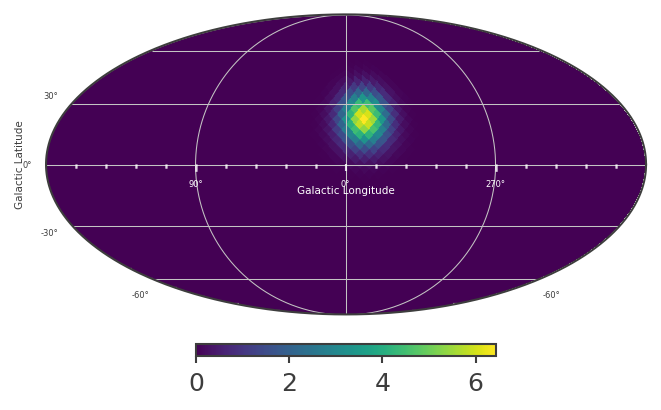

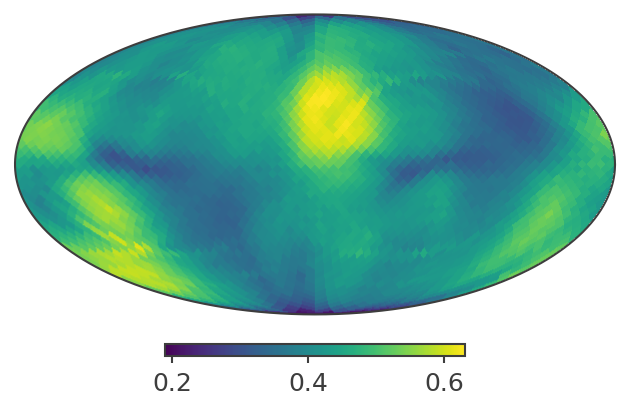

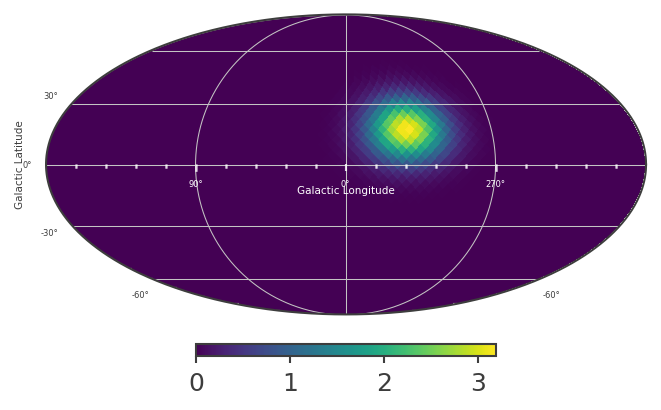

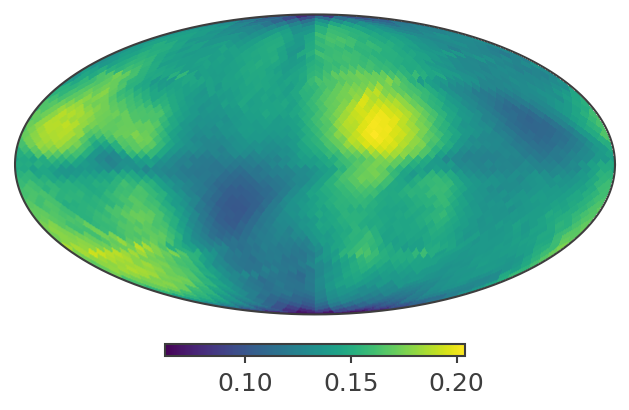

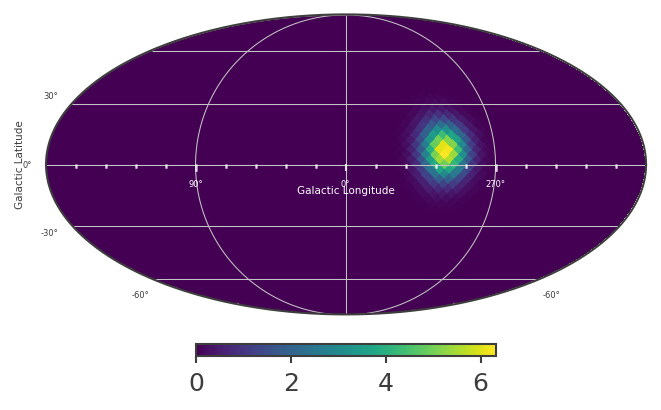

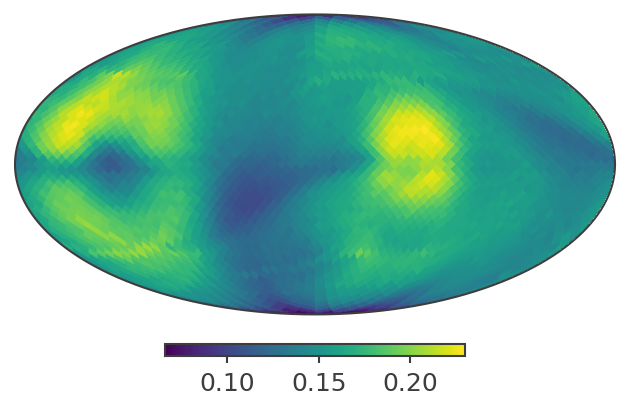

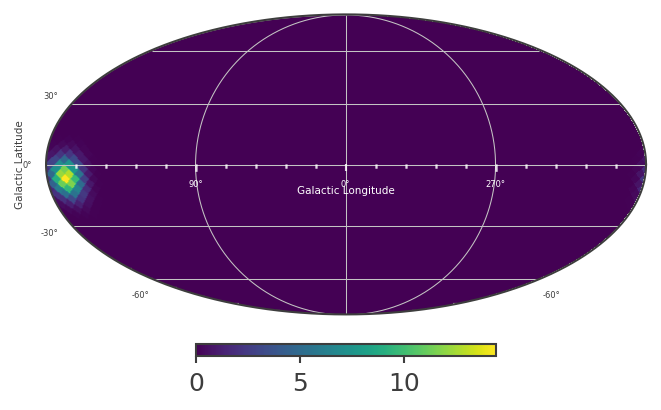

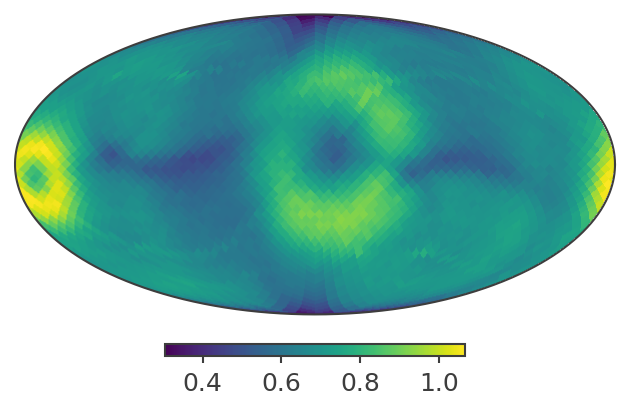

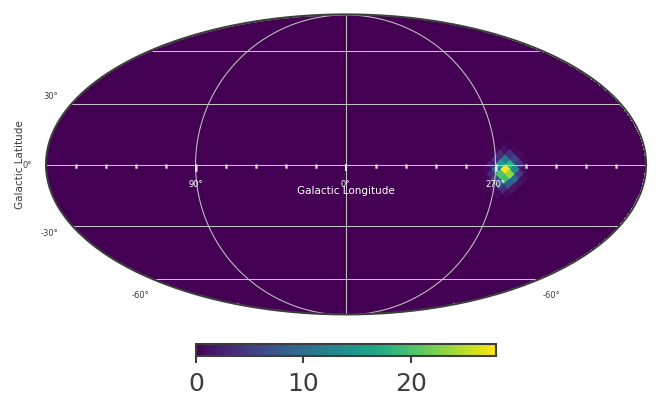

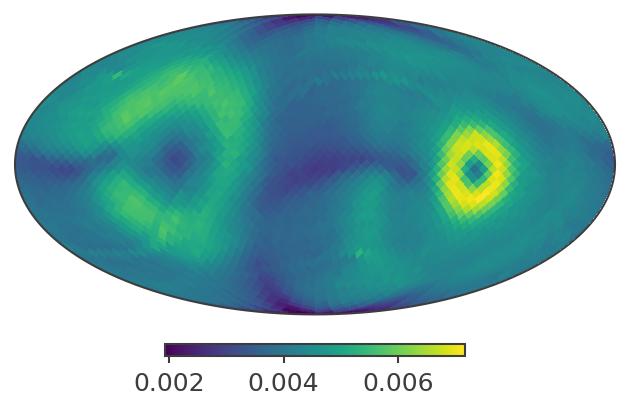

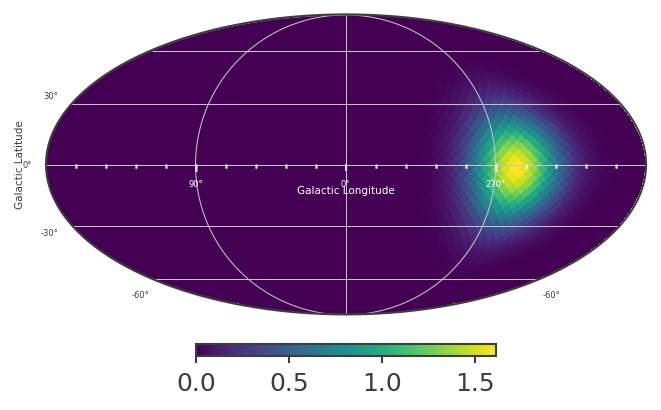

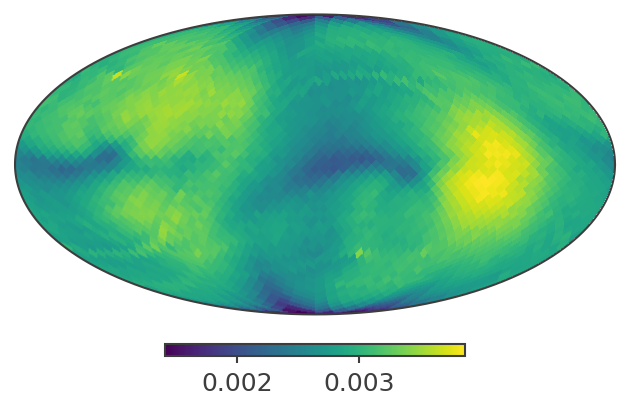

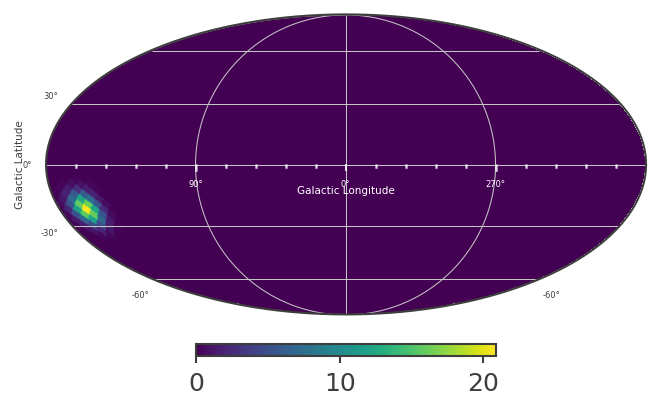

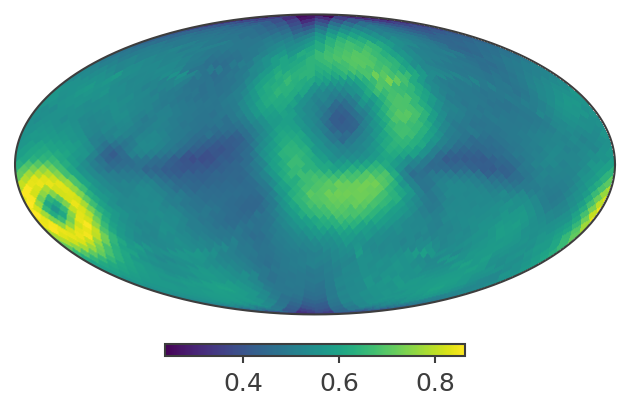

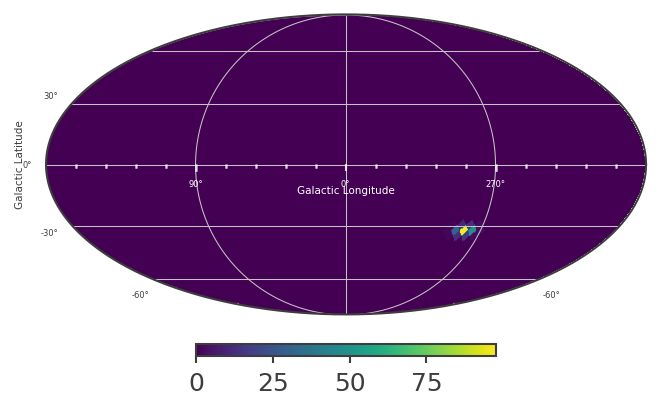

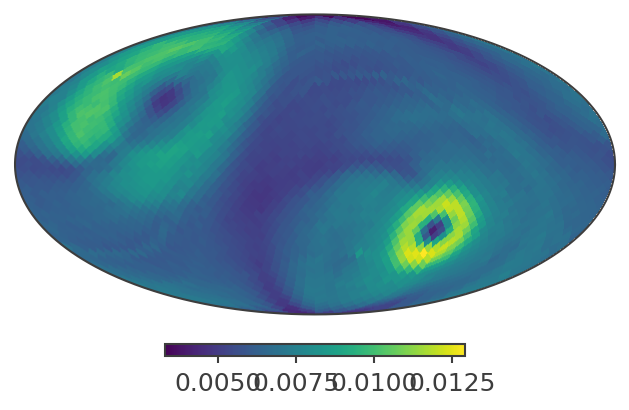

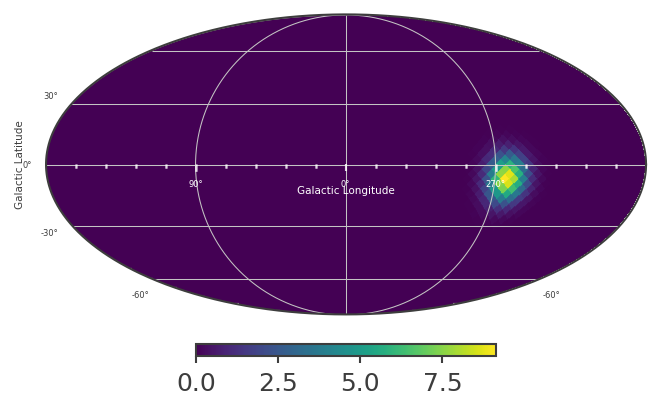

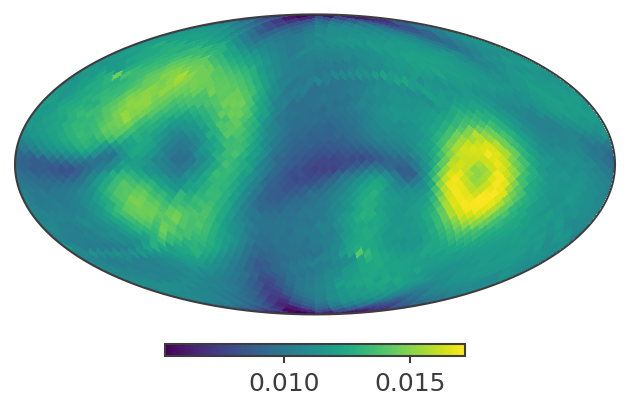

In [158]:
for src in Fe60_sources:
    spectrum, morphology = simulate_extended_sources(Gaussian(), response_path_60Fe_low, src, mu=1173.23)
    plot_morphology(morphology)
    model_injected = Histogram.open(src[0]+'_low.h5')
    model_injected.project('PsiChi').plot()

15:02:25 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=864068;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=62040;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  0.00022500000000000002.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1330.5.   ]8;id=8725;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=360522;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

15:02:27 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=351364;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=336092;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  7.500000000000001e-05.                                                                           

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1330.5.   ]8;id=469085;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=435586;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

15:02:29 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=19844;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=342696;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  7.500000000000001e-05.                                                                           

...

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1330.5.   ]8;id=875564;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=250172;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

15:02:35 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=415415;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=80050;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  2.4999999999999998e-06.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1330.5.   ]8;id=717688;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=700081;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

15:02:36 WARNING   The current value of the parameter F (1.0) was above the new maximum 4e-06.     ]8;id=9290;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=162440;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1330.5.   ]8;id=996727;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=940945;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

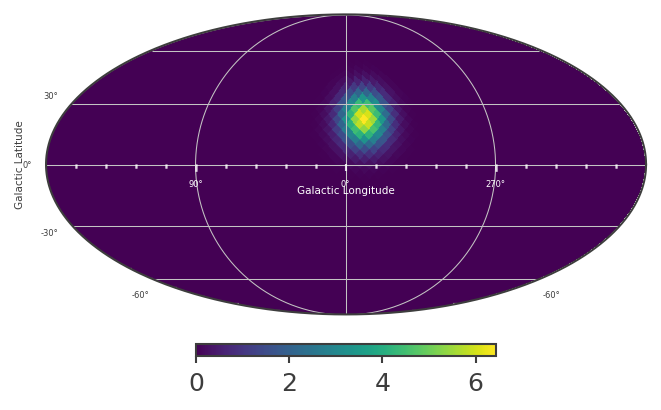

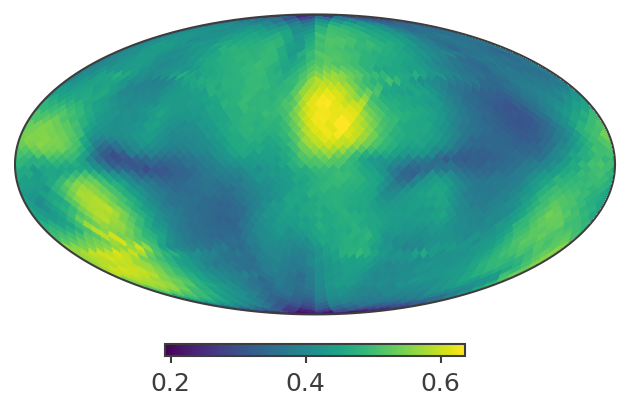

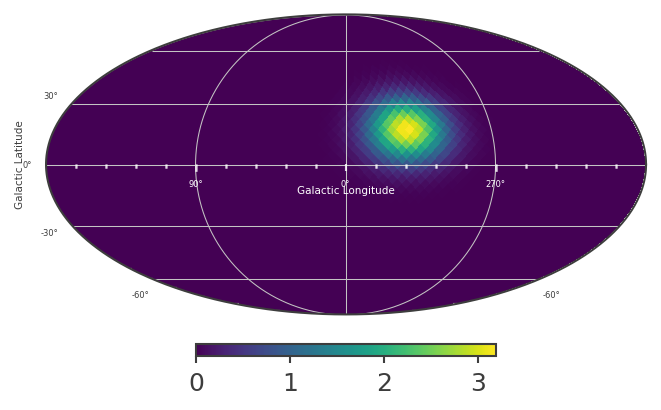

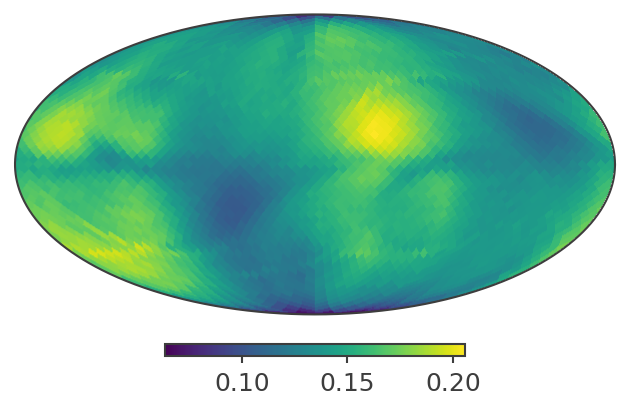

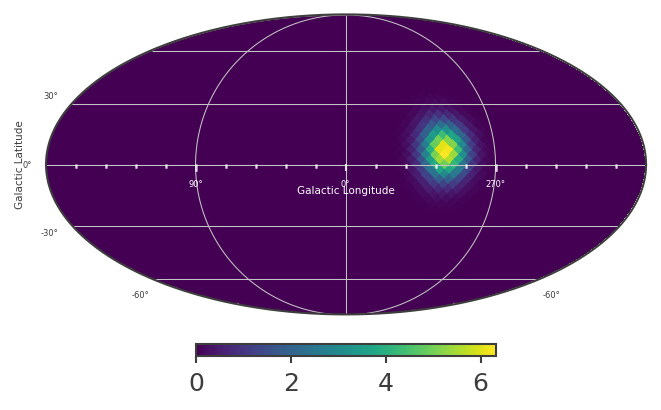

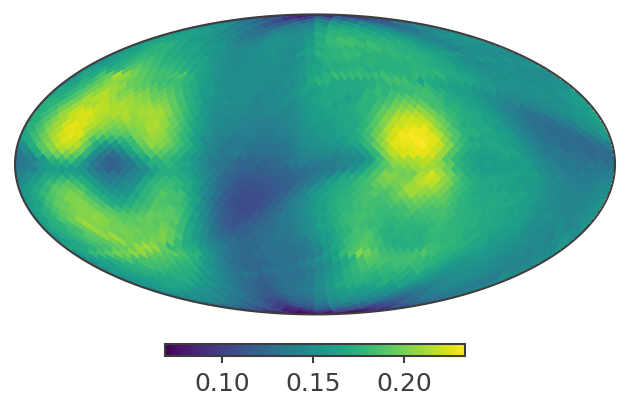

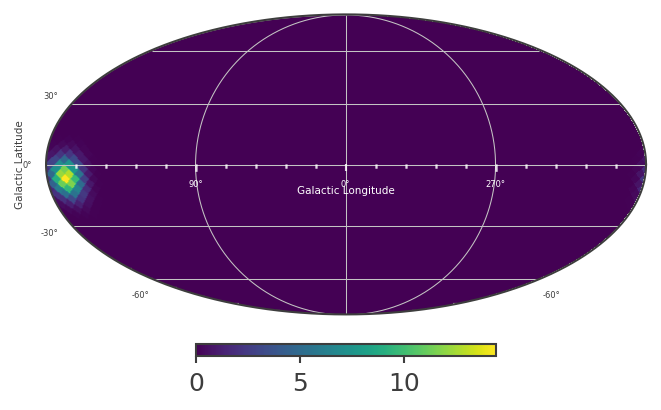

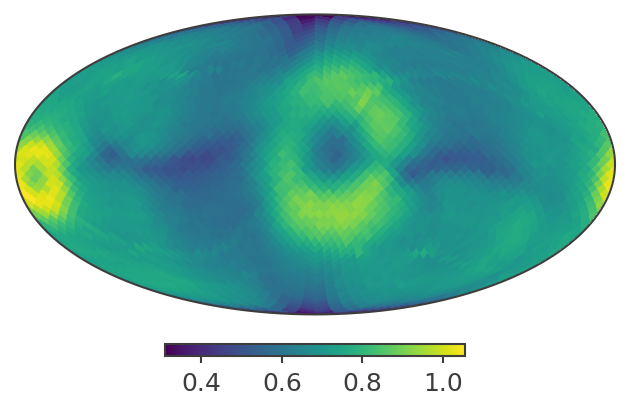

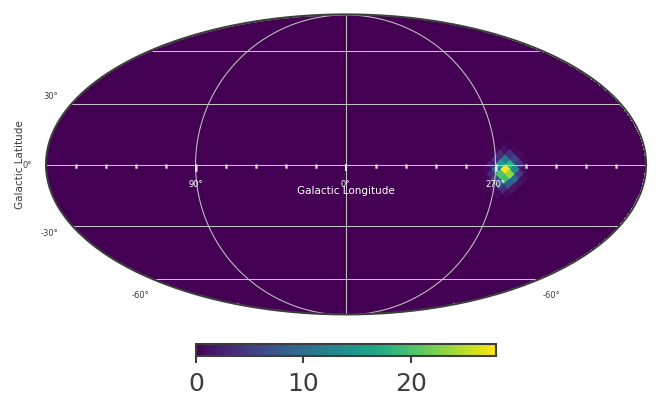

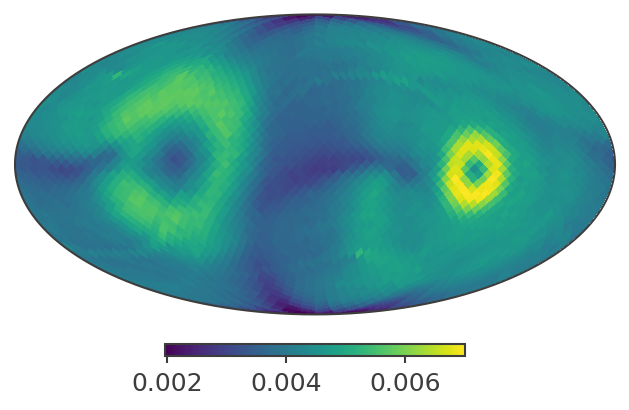

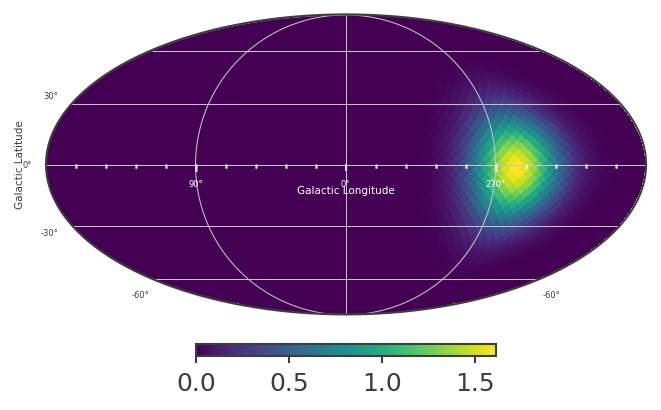

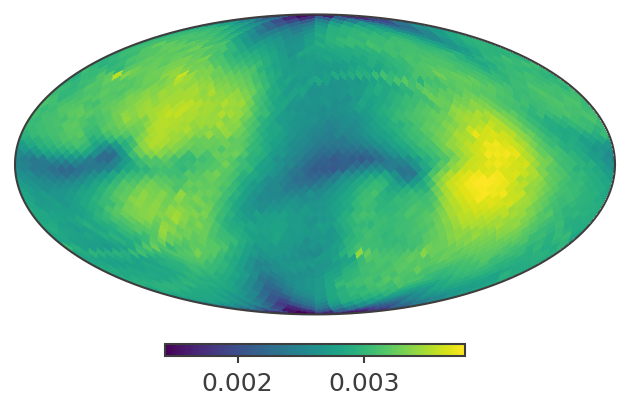

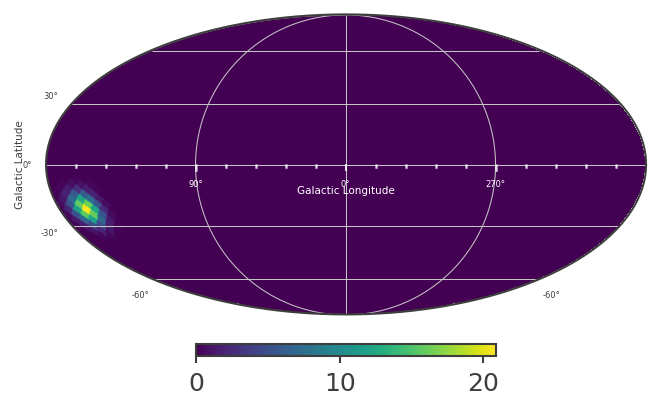

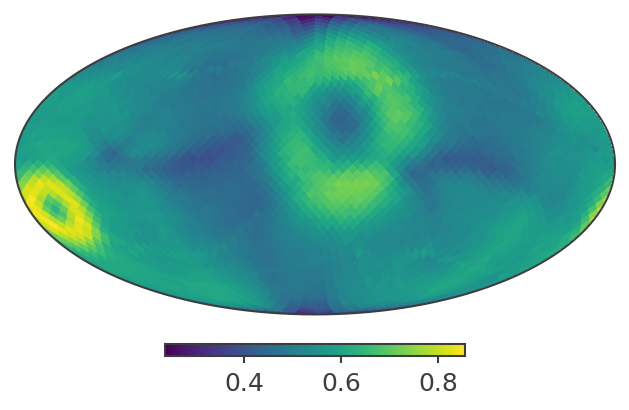

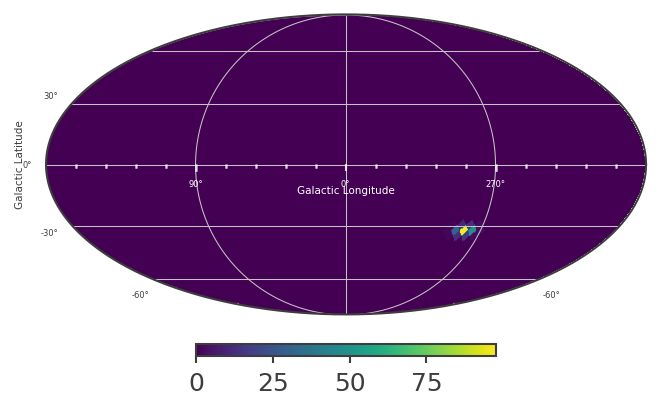

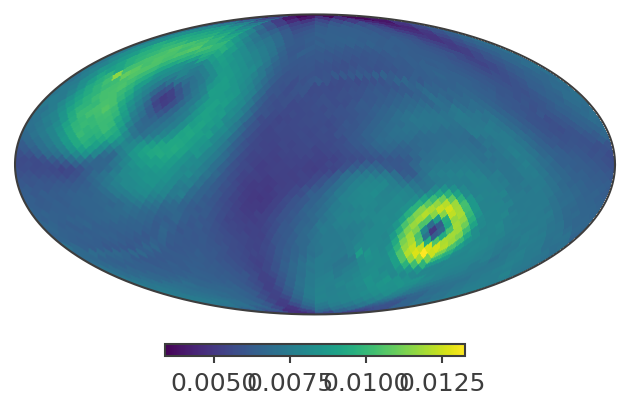

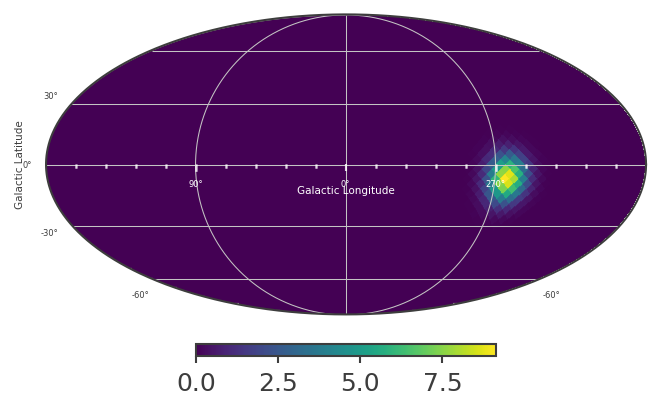

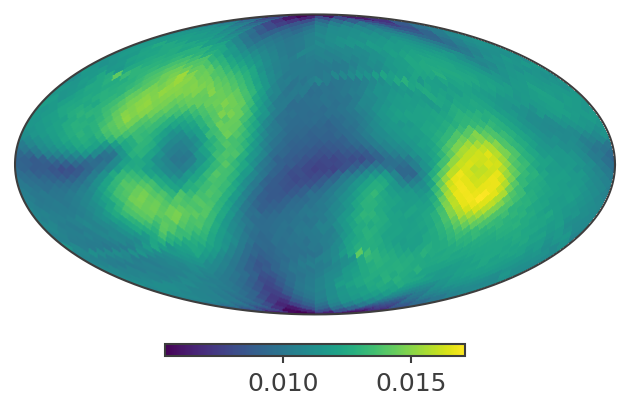

In [160]:
for src in Fe60_sources:
    spectrum, morphology = simulate_extended_sources(Gaussian(), response_path_60Fe_high, src, mu=1332.5)
    plot_morphology(morphology)
    model_injected = Histogram.open(src[0]+'_high.h5')
    model_injected.project('PsiChi').plot()

14:36:48 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=174802;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=746610;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  0.00030000000000000003.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=981099;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=649368;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:36:51 WARNING   The current value of the parameter F (1.0) was above the new maximum 5e-05.     ]8;id=739906;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=220430;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=748437;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=800088;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:36:53 WARNING   The current value of the parameter F (1.0) was above the new maximum 5e-05.     ]8;id=892836;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=991559;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

...

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=711581;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=102307;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:36:58 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=123797;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=717877;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  9.999999999999999e-06.                                                                           

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=697014;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=668346;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

14:36:59 WARNING   The current value of the parameter F (1.0) was above the new maximum 5.5e-06.   ]8;id=160687;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=302538;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=827769;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=510195;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

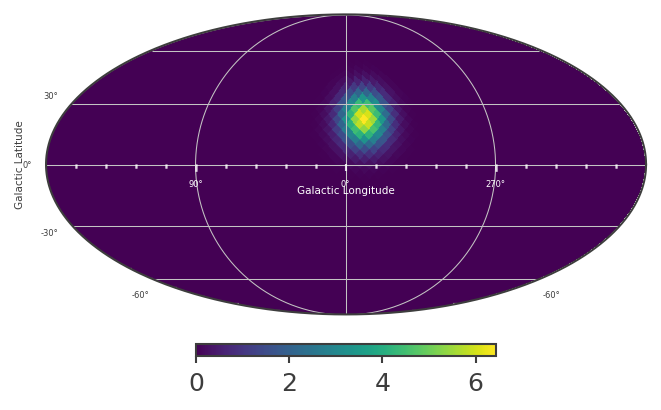

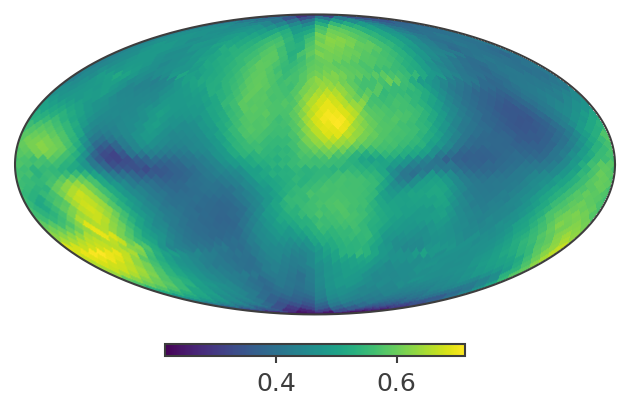

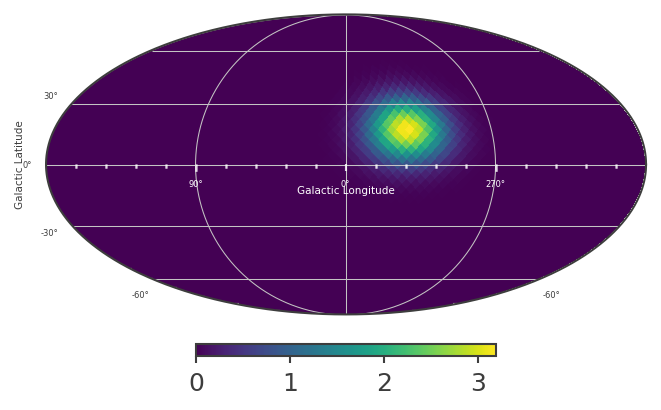

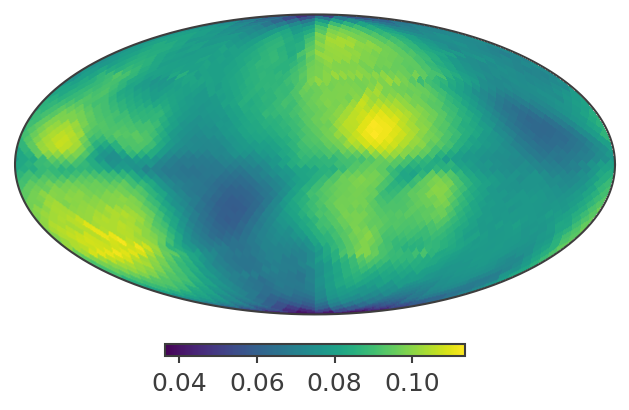

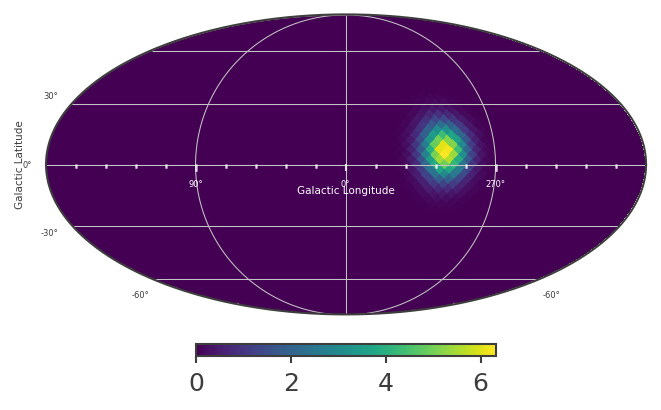

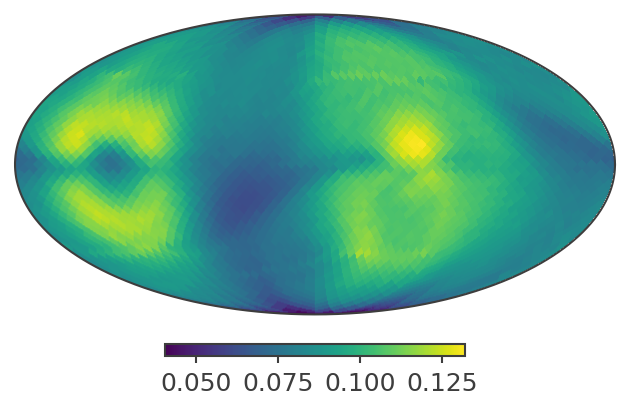

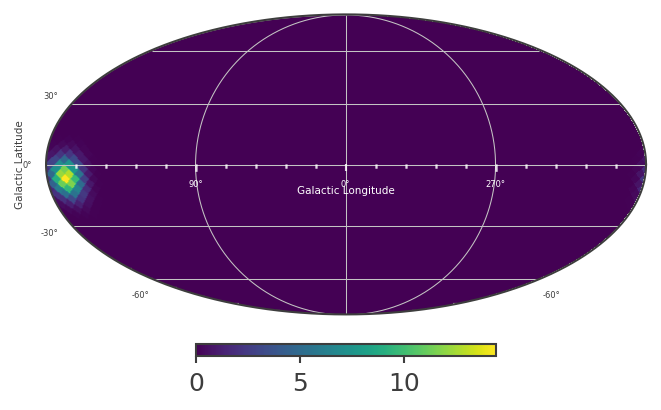

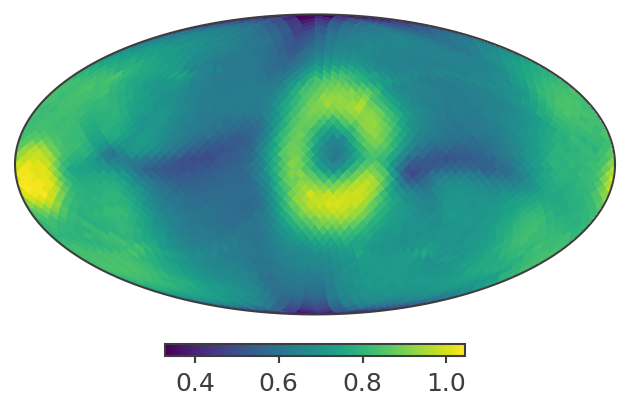

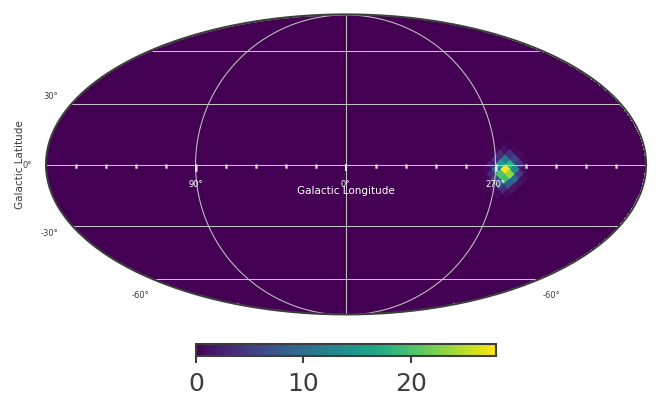

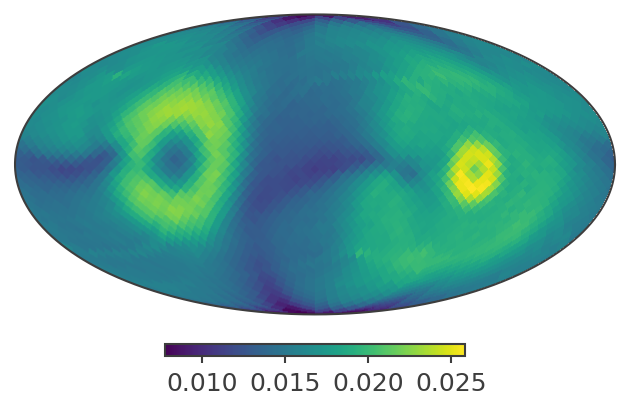

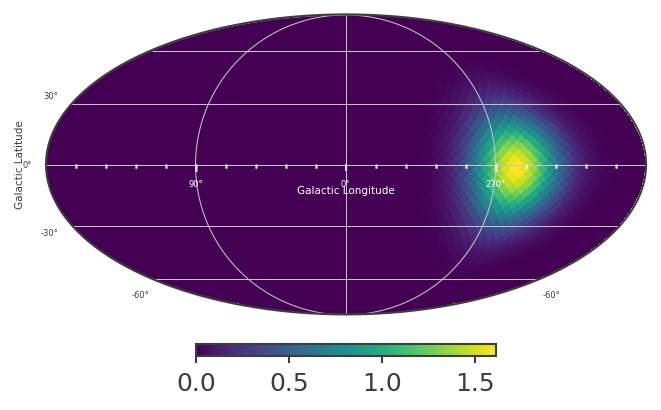

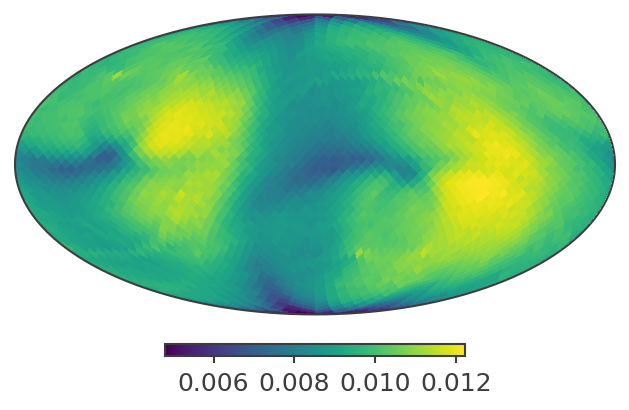

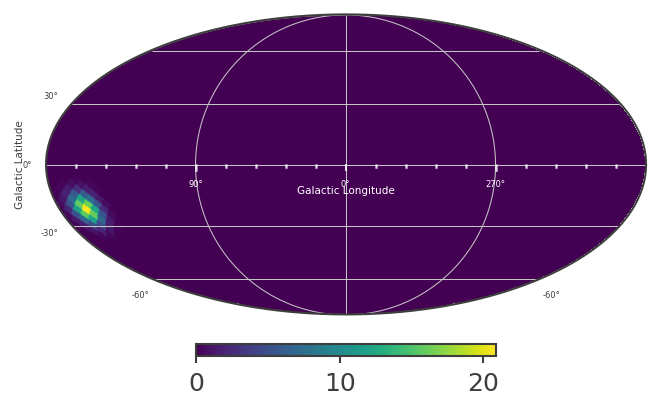

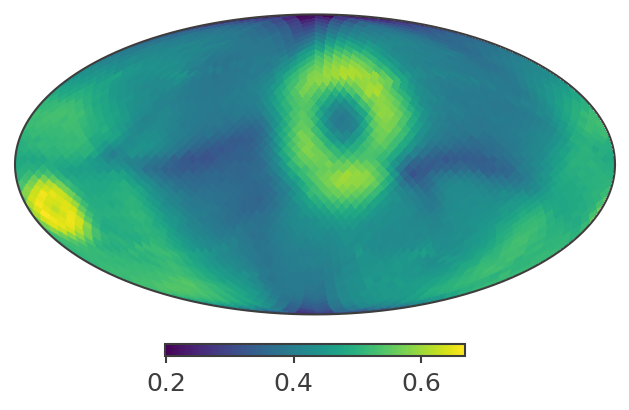

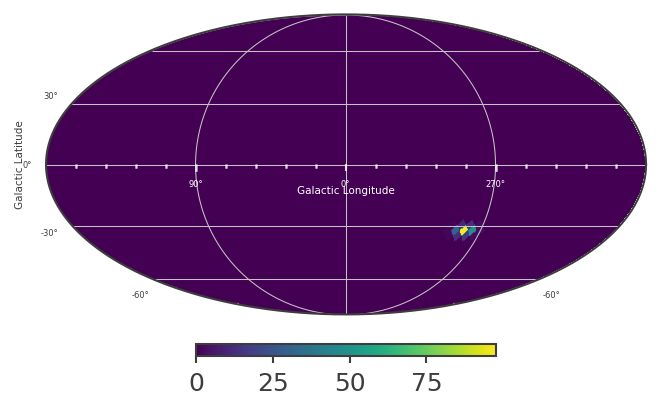

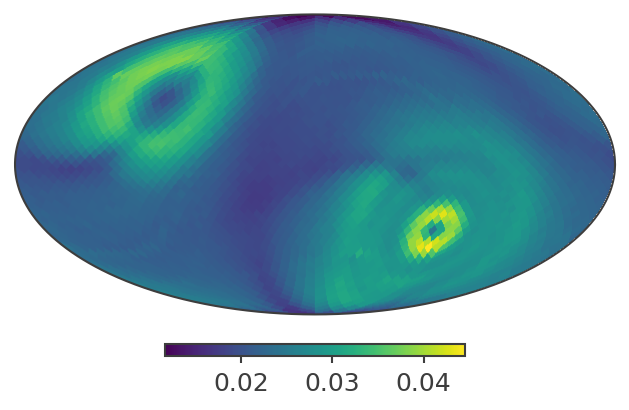

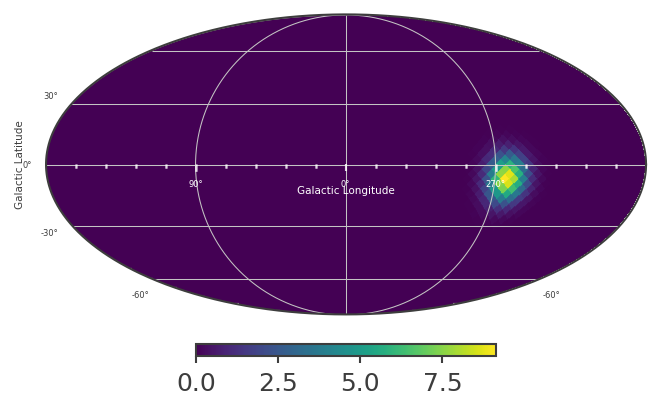

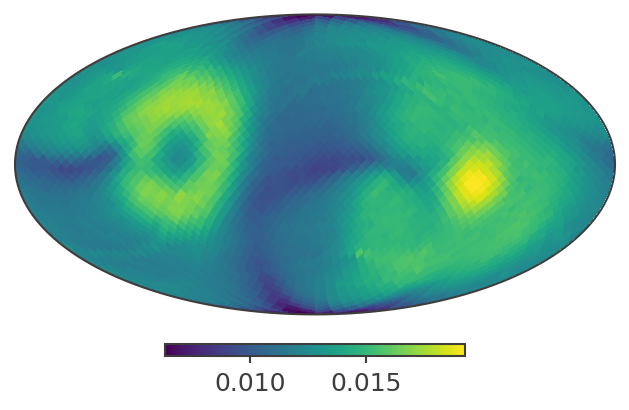

In [147]:
for src in Al26_sources:
    spectrum, morphology = simulate_extended_sources(Gaussian(), response_path_26Al, src, mu=1808.68)
    plot_morphology(morphology)
    model_injected = Histogram.open(src[0]+'.h5')
    model_injected.project('PsiChi').plot()

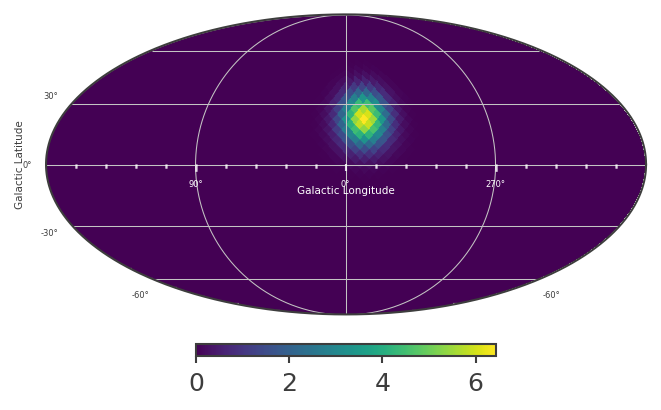

In [128]:
plot_morphology(morphology)

(<Axes: xlabel='Phi [deg]'>, <ErrorbarContainer object of 3 artists>)

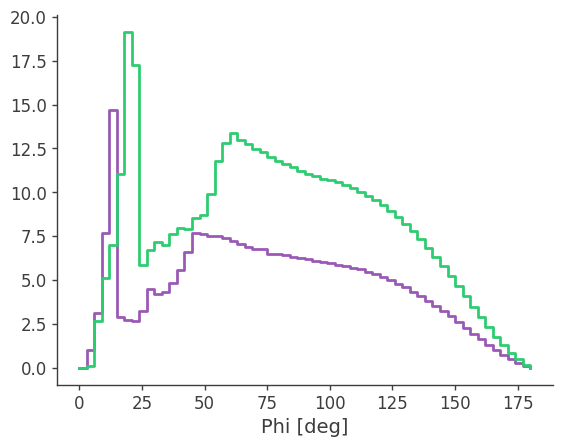

In [163]:
model_injected = Histogram.open('26Al/LCC_26Al.h5')
ax, plot = model_injected.project('Phi').plot()
model_injected = Histogram.open('60Fe/LCC_60Fe_low.h5')
model_injected.project('Phi').plot(ax)